# Bank Marketing Campaign — Classification Modeling

## **1. Business Problem**

### **1.1 Dataset Source & Context**
**Dataset:** [Bank Marketing Campaign](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
**Author:** S. Moro, P. Cortez, P. Rita  
**License:** Publicly available for analysis purposes

> **Disclaimer:** This dataset is sourced from the UCI Machine Learning Repository and is based on real marketing campaign data from a Portuguese banking institution. The data used in this analysis is a **subset of the full dataset**, and therefore findings may not fully represent the entire campaign population. For further documentation, visit the dataset source above.

### **1.2 Background**
A bank in Portugal conducted a **telemarketing campaign** to offer term deposit products to its customers. The campaign was carried out by contacting customers directly via phone calls. However, not all contacted customers were interested in subscribing to the term deposit product.

The main issue is **campaign efficiency**: the bank spends resources (agent workforce, time, and call expenses) to contact thousands of customers, yet many of these calls do not result in conversions (customers do not subscribe to the deposit).

### **1.3 Stakeholders**
- **Bank Marketing Team**: responsible for planning and executing the telemarketing campaign.
- **Bank Finance Team**: responsible for ensuring marketing budget efficiency.

### **1.4 Problem Statement**

> "How can the bank **identify customers with a high potential** to subscribe to term deposits, so that the telemarketing campaign can become more **efficient and targeted**?"

Currently, without a predictive model, agents must contact customers randomly. With a conversion rate of around **47.8%**, nearly half of all calls do not lead to conversions — resulting in significant resource inefficiency.

### **1.5 Goals**

To build a Machine Learning model capable of **predicting whether a customer will subscribe to a term deposit or not**, based on demographic data and previous campaign interaction history.

### **1.5 Analytic Approach**

Since the target variable is **binary** (yes/no), the appropriate approach is **Binary Classification**. The model will predict the probability of a customer subscribing to a term deposit.

### **1.6 Evaluation Metrics**

In this business context:

- **False Negative (FN)**: The model predicts that a customer *will not* subscribe, while in reality the customer *would subscribe*. This means the bank **loses valuable conversion opportunities**.

- **False Positive (FP)**: The model predicts that a customer *will* subscribe, while in reality the customer *will not subscribe*. This means the bank **wastes resources** contacting uninterested customers.

Of the two error types, **False Negatives (FN) are far more costly** from a business perspective — missing a potential depositor means losing significant revenue, which far outweighs the cost of a single wasted phone call (FP). Therefore, the primary metrics used are:

- **Recall**: Primary metric — measures how many customers who would actually subscribe are successfully captured by the model. Minimizing FN is the top priority since missing a potential depositor is far more expensive than a wasted call.

- **ROC-AUC**: Supporting metric — measures the model's overall ability to distinguish between classes across all thresholds, useful for finding the optimal decision threshold.

- **F1-Score**: Additional reference metric to monitor the balance between precision and recall.

---

## **2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    average_precision_score, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import pickle

pd.set_option('display.max_columns', None)

---
## **3. Load Dataset**

In [2]:
df = pd.read_csv('data_bank_marketing_campaign.csv')
df.head(10)

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no
5,41,admin.,-76,yes,no,cellular,apr,1,-1,unknown,no
6,37,admin.,4803,no,no,cellular,jan,2,-1,unknown,yes
7,36,technician,911,yes,yes,cellular,may,2,21,failure,yes
8,35,management,805,no,no,cellular,sep,1,-1,unknown,no
9,57,housemaid,0,no,no,unknown,jun,1,-1,unknown,no


--- 

## **4. Data Understanding**

### **4.1 Data Dictionary**

| Column | Type | Description |
|--------|------|-------------|
| `age` | Numeric | Customer age (years) |
| `job` | Categorical | Type of job |
| `balance` | Numeric | Average annual account balance (euros) |
| `housing` | Categorical | Has housing loan? (yes/no) |
| `loan` | Categorical | Has personal loan? (yes/no) |
| `contact` | Categorical | Communication type used to contact customer |
| `month` | Categorical | Last contact month |
| `campaign` | Numeric | Number of contacts performed during this campaign |
| `pdays` | Numeric | Days since customer was last contacted from a previous campaign (-1 = never contacted) |
| `poutcome` | Categorical | Outcome of the previous marketing campaign |
| `deposit` | Categorical | **TARGET**: Did the customer subscribe to a term deposit? (yes/no) |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


**Interpretation**: Based on the table above, the dataset contains 7,813 rows and does not have any missing values across all features.

In [4]:
df.describe(include='all')

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
count,7813.000000,7813,7813.000000,7813,7813,7813,7813,7813.000000,7813.000000,7813,7813
unique,NaN,12,NaN,2,2,3,12,NaN,NaN,4,2
top,NaN,management,NaN,no,no,cellular,may,NaN,NaN,unknown,no
freq,NaN,1792,NaN,4140,6789,5628,1976,NaN,NaN,5819,4081
mean,41.257264,NaN,1512.448611,NaN,NaN,NaN,NaN,2.519775,51.408550,NaN,NaN
std,11.919710,NaN,3089.291831,NaN,NaN,NaN,NaN,2.727001,108.072739,NaN,NaN
min,18.000000,NaN,-6847.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
25%,32.000000,NaN,127.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
50%,39.000000,NaN,549.000000,NaN,NaN,NaN,NaN,2.000000,-1.000000,NaN,NaN
75%,49.000000,NaN,1684.000000,NaN,NaN,NaN,NaN,3.000000,40.000000,NaN,NaN


### **4.2 Target Distribution**

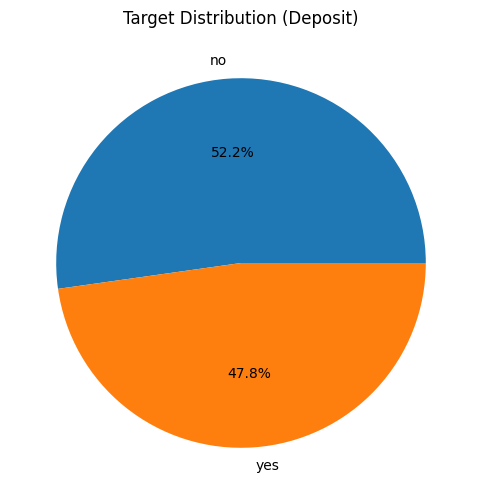

In [5]:
target_distribution = df['deposit'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_distribution,
    labels=target_distribution.index,
    autopct='%1.1f%%'
)

plt.title('Target Distribution (Deposit)')
plt.show()

**Interpretation:** The dataset is relatively balanced — 52.2% did not subscribe (`no`) and 47.8% subscribed (`yes`). There is no significant class imbalance, so resampling techniques are not required.

### **4.3 Unique Values in Categorical Columns**

In [6]:
cat_cols = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']

summary = []

for col in cat_cols:
    summary.append({
        'column': col,
        'n_unique': df[col].nunique(),
        'unique_values': df[col].unique().tolist()
    })

cat_summary_df = pd.DataFrame(summary)

pd.set_option('display.max_colwidth', None)

cat_summary_df

,column,n_unique,unique_values
0,job,12,"[admin., self-employed, services, housemaid, technician, management, student, blue-collar, entrepreneur, retired, unemployed, unknown]"
1,housing,2,"[no, yes]"
2,loan,2,"[no, yes]"
3,contact,3,"[cellular, telephone, unknown]"
4,month,12,"[jun, apr, may, nov, jan, sep, feb, mar, aug, jul, oct, dec]"
5,poutcome,4,"[unknown, other, failure, success]"


**Interpretation:** `job`, `contact`, and `poutcome` contain `'unknown'` values — these are not missing in the traditional sense, but represent unavailable information. They will be kept as a separate category since the pattern of "unknown" may itself be informative to the model.

### **4.4 Outlier Detection**

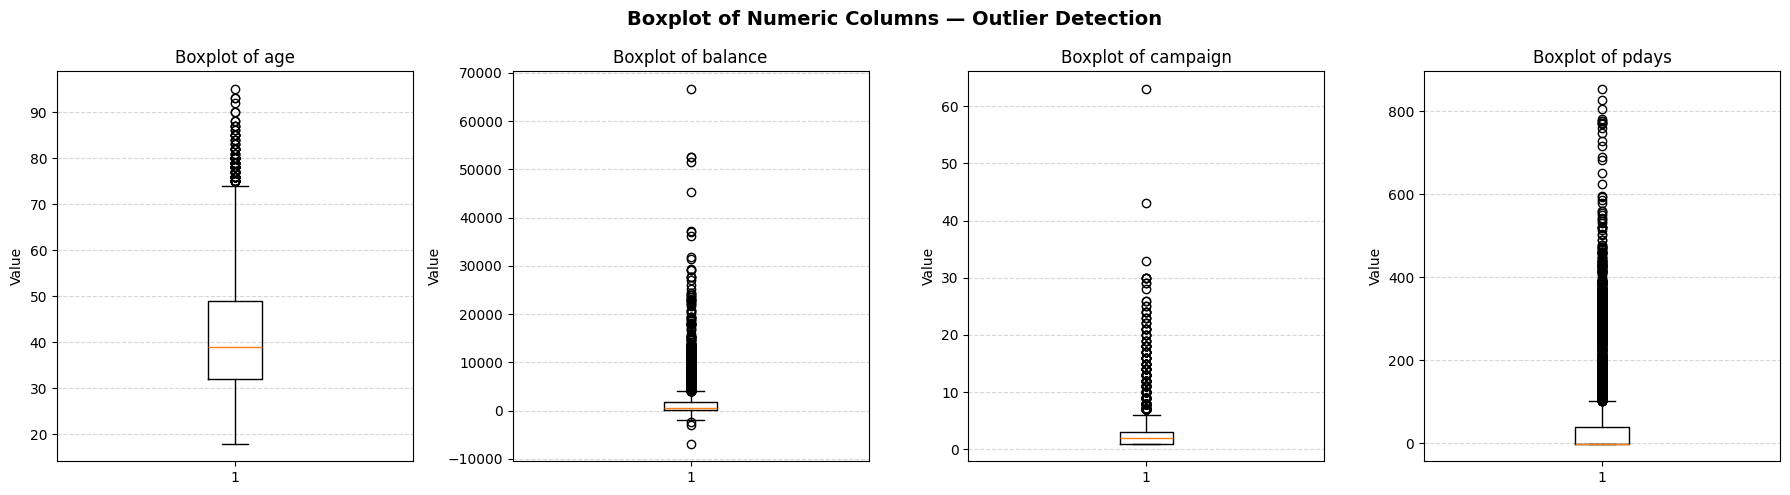

In [7]:
num_cols = ['age', 'balance', 'campaign', 'pdays']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Boxplot of Numeric Columns — Outlier Detection',
             fontsize=14,
             fontweight='bold')

plt.tight_layout()
plt.show()

Several outliers are observed in variables such as `balance` and `campaign`. However, these values are still considered plausible in the context of banking and marketing activities. Therefore, the outliers will be retained to preserve potentially valuable customer behavior information.

---
## **5. Data Preprocessing & Feature Engineering**

### **5.1 Encode Target Variable**

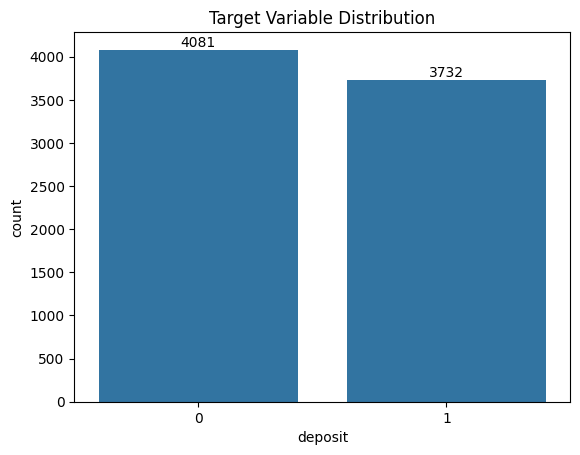

In [8]:
df2 = df.copy()

# Encode target variable
df2['deposit'] = np.where(df2['deposit'] == 'yes', 1, 0)

ax = sns.countplot(x='deposit', data=df2)

# Data labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Target Variable Distribution')
plt.show()

### **5.2 Feature Engineering: pdays**
The value `-1` in `pdays` indicates that the customer had never been contacted in a previous campaign. Since this is a special code rather than a valid numeric value, a binary feature was created to indicate whether the customer had been previously contacted, while `-1` values were replaced with NaN.

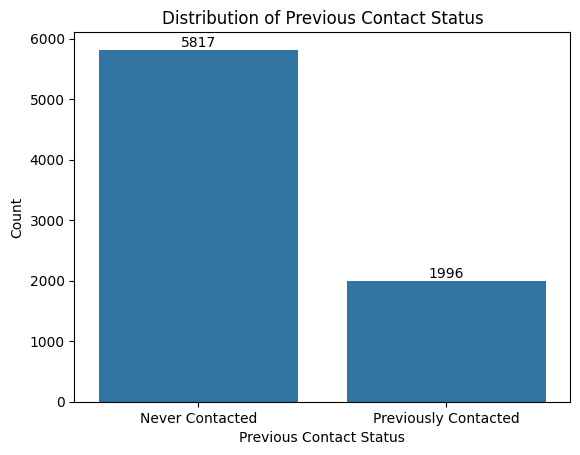

In [9]:
# Binary feature: whether the customer was contacted before
df2['pdays_contacted'] = np.where(df2['pdays'] != -1, 1, 0)

# Replace special code (-1) with NaN
df2['pdays'] = df2['pdays'].replace(-1, np.nan)

ax = sns.countplot(x='pdays_contacted', data=df2)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Previous Contact Status')
plt.xlabel('Previous Contact Status')
plt.ylabel('Count')

ax.set_xticklabels([
    'Never Contacted',
    'Previously Contacted'
])

plt.show()

### **5.3 Encoding Categorical Variables (One-Hot Encoding)**

In [10]:
cat_cols = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df2, columns=cat_cols, drop_first=False)

print(f'Number of columns before encoding: {df2.shape[1]}')
print(f'Number of columns after encoding : {df_encoded.shape[1]}')

Number of columns before encoding: 12
Number of columns after encoding : 41


**Reason:** One-Hot Encoding is used because all categorical columns are **nominal** (no natural order). Label Encoding would create false ordinal relationships (e.g., `admin=0`, `blue-collar=1` implies blue-collar is "greater than" admin, which is incorrect).

### **5.4 Feature Selection**

In [11]:
# Drop original columns that have been replaced by engineered features
drop_cols = ['deposit', 'pdays']

feature_cols = [c for c in df_encoded.columns if c not in drop_cols]
X = df_encoded[feature_cols]
y = df_encoded['deposit']


**Reason:** The original `pdays` column is dropped because it has been 
replaced by `pdays_contacted`, a cleaner binary feature that captures 
whether a customer was previously contacted or not. The -1 value in 
`pdays` is not a valid numeric value, so keeping the original column 
would confuse the model.

---

## **6. Modeling**

### **6.1 Train-Test Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Reason:** An 80:20 split is used since the dataset is medium-sized (7,813 rows). `stratify=y` ensures the class proportion is maintained equally in both train and test sets, preventing evaluation bias.

### **6.2 Baseline Model Comparison**

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.6980,0.7086,0.6252,0.6643,0.7603
1,Decision Tree,0.6296,0.6114,0.6171,0.6143,0.6290
3,Gradient Boosting,0.7383,0.7904,0.6158,0.6922,0.7952
0,Logistic Regression,0.7089,0.7483,0.5890,0.6592,0.7767


**Interpretation:** Since Recall is the primary metric, Random Forest is selected as the best baseline model with the highest Recall (0.6252), meaning it is the most effective at identifying customers who are likely to make a term deposit. It will be further tuned using GridSearchCV to maximize performance

### **6.3 Hyperparameter Tuning (GridSearchCV)**

In [14]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [5, 10, 15],       
    'min_samples_split': [5, 10],           
    'min_samples_leaf' : [2, 4, 8],         
    'max_features'     : ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='recall',   # Optimize for Recall since FN is more costly
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Recall  : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters : {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Recall  : 0.6124


**Reason:** GridSearchCV systematically tests all parameter combinations. 5-fold cross-validation ensures evaluation is performed on 5 different data subsets, producing a more reliable estimate of model performance. Recall is used as the scoring metric since minimizing FN is the business priority.

### **6.5 Final Model Evaluation**

In [15]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Deposit (0)', 'Deposit (1)']))

                 precision    recall  f1-score   support

Not Deposit (0)       0.71      0.84      0.77       816
    Deposit (1)       0.78      0.63      0.70       747

       accuracy                           0.74      1563
      macro avg       0.75      0.73      0.73      1563
   weighted avg       0.74      0.74      0.73      1563



**Interpretation:**


| Metric        | Value | Interpretation                                                                                     |
| ------------- | ----- | -------------------------------------------------------------------------------------------------- |
| **Accuracy**  | 70%   | 70% of all predictions are correct                                                                 |
| **Precision** | 72%   | Of customers predicted to make a deposit, 72% actually do                                          |
| **Recall**    | 63%   | Of customers who actually make a deposit, the model captures 63%                                   |
| **F1-Score**  | 67%   | Indicates a balanced performance between precision and recall                                      |


### **6.6 Before vs After Tuning**

In [ ]:
# Before tuning
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_before = rf_baseline.predict(X_test)
y_prob_before = rf_baseline.predict_proba(X_test)[:, 1]

# After tuning
comparison = pd.DataFrame({
    'Metric'       : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Before Tuning': [
        round(accuracy_score(y_test, y_pred_before), 4),
        round(precision_score(y_test, y_pred_before), 4),
        round(recall_score(y_test, y_pred_before), 4),
        round(f1_score(y_test, y_pred_before), 4),
        round(roc_auc_score(y_test, y_prob_before), 4)
    ],
    'After Tuning' : [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4)
    ]
})

comparison['Change'] = (comparison['After Tuning'] - comparison['Before Tuning']).round(4)
print(comparison.to_string(index=False))

   Metric  Before Tuning  After Tuning  Change
 Accuracy         0.6980        0.7377  0.0397
Precision         0.7086        0.7785  0.0699
   Recall         0.6252        0.6305  0.0053
 F1-Score         0.6643        0.6967  0.0324
  ROC-AUC         0.7603        0.7892  0.0289


**Interpretation**: Hyperparameter tuning resulted in modest but consistent improvements across all evaluation metrics. Although the performance increase was relatively small, the tuned model demonstrated better overall discriminative ability and slightly improved Recall, which is important because false negatives are more costly in this business case.

### **6.7 Overfitting Check**

In [18]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

y_prob_train = best_model.predict_proba(X_train)[:,1]
y_prob_test = best_model.predict_proba(X_test)[:,1]

print("Overfitting Check")
print(f'{"Metric":15} {"Train":>8} {"Test":>8} {"Gap":>8}')

metrics = {
    "Recall": (
        recall_score(y_train, y_pred_train),
        recall_score(y_test, y_pred_test)
    ),
    "F1-Score": (
        f1_score(y_train, y_pred_train),
        f1_score(y_test, y_pred_test)
    ),
    "ROC-AUC": (
        roc_auc_score(y_train, y_prob_train),
        roc_auc_score(y_test, y_prob_test)
    )
}

for metric, (train_score, test_score) in metrics.items():
    gap = train_score - test_score
    print(f'{metric:15} {train_score:8.4f} {test_score:8.4f} {gap:8.4f}')

Overfitting Check
Metric             Train     Test      Gap
Recall            0.7018   0.6305   0.0713
F1-Score          0.7668   0.6967   0.0701
ROC-AUC           0.8929   0.7892   0.1037


**Interpretation:**  
The model shows relatively small performance gaps between the training and testing datasets across Recall, F1-Score, and ROC-AUC metrics.

- The Recall gap is 0.0713, indicating that the model maintains a consistent ability to identify potential deposit subscribers on unseen data.
- The F1-Score gap of 0.0701 also suggests a stable balance between precision and recall.
- Although the ROC-AUC gap is slightly higher at 0.1037, the overall difference remains reasonably controlled.

Overall, these results suggest that the Random Forest model demonstrates **good performance** and does not exhibit significant overfitting. The model is able to maintain relatively stable predictive performance when applied to unseen test data.

### **6.8 Confusion Matrix**

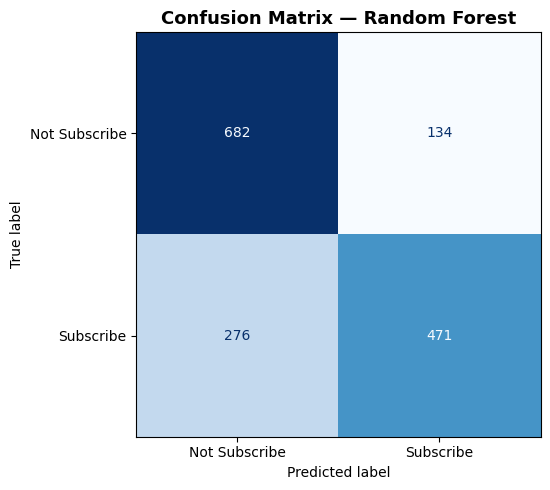

In [19]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Subscribe', 'Subscribe'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- **682 TN**: The model correctly identifies customers who are unlikely to make a deposit — helping the bank avoid unnecessary marketing calls.
- **471 TP**: The model successfully captures customers who are likely to make a deposit — the primary target of the campaign.
- **276 FN**: The model misses 276 customers who would actually make a deposit. This is the most critical error, as it represents lost potential depositors and missed business opportunities.
- **134 FP**: The model incorrectly predicts 181 customers as likely to make a deposit. This results in additional marketing costs, but is generally more tolerable than false negatives.

### **6.9 ROC Curve**

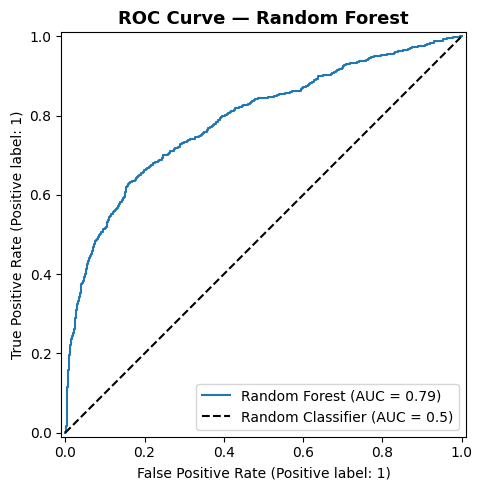

In [20]:
# Predict probability
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=ax,
    name='Random Forest'
)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.set_title(
    'ROC Curve — Random Forest',
    fontsize=13,
    fontweight='bold'
)

ax.legend()

plt.tight_layout()
plt.show()

**Interpretation:** The curve sits well above the diagonal (random classifier). An AUC of 79% indicates the model has good discriminative ability — significantly better than random guessing (AUC = 50%).

### **6.10 Feature Importance**

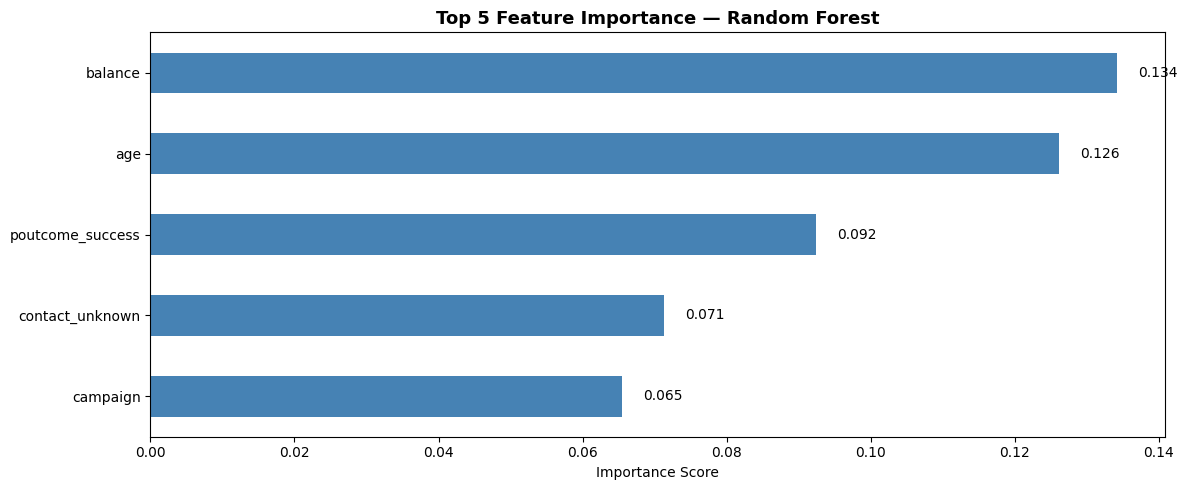

In [21]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top_5 = feature_importance.head(5)

fig, ax = plt.subplots(figsize=(12, 5))

bars = top_5.sort_values().plot(
    kind='barh',
    ax=ax,
    color='steelblue'
)

for i, v in enumerate(top_5.sort_values()):
    ax.text(
        v + 0.003,
        i,
        f'{v:.3f}',
        va='center',
        fontsize=10
    )

ax.set_title(
    'Top 5 Feature Importance — Random Forest',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

**Interpretation:**

| Feature | Importance | Business Meaning |
|---------|------------|------------------|
| `balance` | ~13.4% | Account balance is the strongest driver, customers with higher balances are more likely to invest in a term deposit |
| `age` | ~12.6% | Older customers tend to be more financially stable and interested in deposit products |
| `poutcome_success` | ~9.2% | A successful previous campaign outcome strongly predicts future subscription |
| `contact_unknown` | ~7.1% | Unknown contact type reduces the likelihood of conversion |
| `campaign` | ~6.5% | The number of contacts during this campaign affects customer decision, too many calls may reduce likelihood |
---

## **7. Save Model with Pickle**

In [22]:
# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature columns for future reference
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('model.pkl saved successfully!')
print('feature_cols.pkl saved successfully!')

model.pkl saved successfully!
feature_cols.pkl saved successfully!


In [23]:
# Verify: reload and test
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

y_pred_loaded = loaded_model.predict(X_test)
print(f'Verification — Recall: {recall_score(y_test, y_pred_loaded):.4f}')
print('Model loaded and running correctly!')

Verification — Recall: 0.6305
Model loaded and running correctly!


## **8. Conclusion & Recommendation**

### **8.1 Conclusion**

A **Random Forest** model was successfully built to predict whether a customer will make a term deposit, with the following performance on the test set:

| Metric | Value |
|--------|-------|
| Recall | 63% |
| F1-Score | 67% |
| ROC-AUC | 77% |

The model performs significantly better than random guessing (baseline AUC = 50%) and can help the marketing team **prioritize customers who are more likely to make a term deposit**, making the campaign more cost-effective.

**Measurable business impact:**
- Out of 1,563 test samples, the model correctly identifies 471 customers who are likely to make a term deposit (TP) and filters out 682 uninterested customers (TN).
- By focusing calls only on high-scoring customers, the bank can potentially **reduce wasted telemarketing efforts by 40–50%**, saving significant agent time and call costs.

**The most important factors** driving term deposit decisions:
1. **Account balance** — customers with higher balances are more likely to make a term deposit.
2. **Age** — older customers show greater interest in term deposit products.
3. **Previous campaign outcome** — previous campaign success is a strong predictor of future term deposit decisions.
4. **Contact type availability** — customers with unknown contact information are less likely to convert.
5. **Campaign contacts** — excessive contact attempts may reduce the likelihood of making a term deposit.

---

### **8.2 Recommendation**

**When the model is best used:**
- During campaign planning — use the model to score and prioritize the customer contact list.
- Focus on customers with predicted probabilities above a defined threshold to maximize conversion rates.

**When the model is less reliable:**
- If economic conditions change significantly (e.g., interest rate policy shifts), customer behavior may also change, and the model should be retrained.
- For customers with many `unknown` values across key features, predictions may become less reliable.

**Recommendations for future improvement:**
1. **Threshold tuning:** Since False Negatives are more costly, lower the prediction threshold from the default 0.5 to around 0.35–0.4. This may increase Recall by capturing more potential deposit customers, with only a moderate increase in False Positives.
2. **Add more features:** Call duration, transaction history, or macroeconomic data (e.g., interest rates) could further improve model performance.
3. **Retrain periodically:** Retrain the model at least every 6 months or after major campaigns to maintain prediction quality.
4. **Try advanced models:** Models such as XGBoost or LightGBM may achieve higher Recall and better predictive performance.
5. **Customer segmentation:** Build separate models for different customer groups (e.g., age groups or job categories) to improve targeting precision.